**9.5 Outlier Treatment**

Steps:
1. Load encoded train and test sets
2. Plot boxplots for sample numeric features
3. Compute IQR bounds
4. Cap outliers on numeric columns
5. Save outlier treated data

Note: Outlier treatment happens before scaling.

**1. Setup**

In [7]:
%pip install -q pandas numpy matplotlib seaborn


[notice] A new release of pip is available: 25.1.1 -> 25.3
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

pd.set_option("display.max_columns", None)
sns.set_theme(style="whitegrid")

**2. Load encoded data**

In [2]:
train_df = pd.read_csv("titanic_train_encoded.csv")
test_df = pd.read_csv("titanic_test_encoded.csv")

target = "survived"

X_train = train_df.drop(columns=[target])
y_train = train_df[target]

X_test = test_df.drop(columns=[target])
y_test = test_df[target]


print("Train shape:", X_train.shape)
print("Test shape :", X_test.shape)

Train shape: (712, 18)
Test shape : (179, 18)


**3. Boxplots for a few useful numeric features if present**

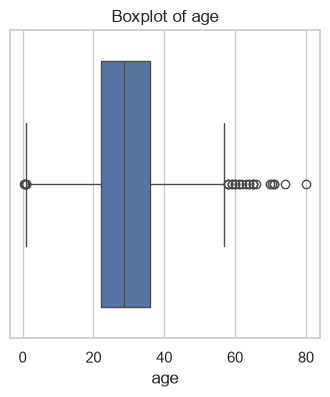

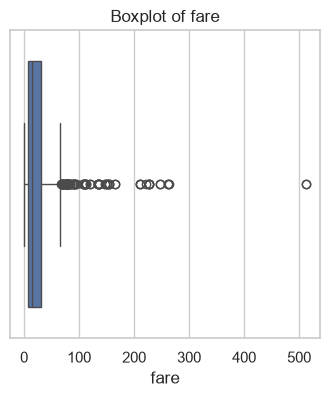

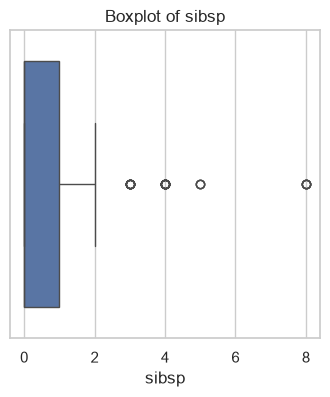

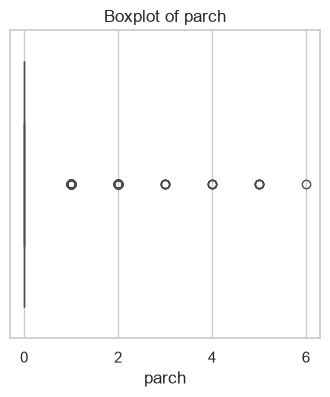

In [3]:
num_cols = ["age", "fare", "sibsp", "parch"]

for col in num_cols:
    plt.figure(figsize=(4, 4))
    sns.boxplot(x=X_train[col])
    plt.title(f"Boxplot of {col}")
    plt.show()

In [8]:
valid_outlier_columns = ["age", "fare"]

**4. Functions for IQR and Capping**

In [4]:
def iqr_bounds(series):
    Q1 = series.quantile(0.25)
    Q3 = series.quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    return lower, upper

In [5]:
# compute bounds only from TRAIN data
def compute_train_bounds(df, cols):
    bounds = {}
    for col in cols:
        low, high = iqr_bounds(df[col])
        bounds[col] = (low, high)
    return bounds


In [6]:
# apply the same bounds to any set (train or test)
def cap_outliers_with_bounds(df, bounds):
    df_capped = df.copy()
    for col, (low, high) in bounds.items():
        df_capped[col] = np.where(df_capped[col] < low, low, df_capped[col])   # np.where(condition, value_if_true, value_if_false) 
        df_capped[col] = np.where(df_capped[col] > high, high, df_capped[col])
    return df_capped

In [9]:
# compute bounds from TRAIN data only
train_bounds = compute_train_bounds(X_train, valid_outlier_columns)

In [10]:
train_bounds

{'age': (np.float64(1.0), np.float64(57.0)),
 'fare': (np.float64(-26.7605), np.float64(65.6563))}

**5. Apply capping**

In [11]:
# cap both training data and test dataset with TRAIN bounds
X_train_capped = cap_outliers_with_bounds(X_train, train_bounds)
X_test_capped = cap_outliers_with_bounds(X_test, train_bounds)

In [12]:
print("\nShapes after outlier capping:")
print("X_train_capped:", X_train_capped.shape)
print("X_test_capped :", X_test_capped.shape)


Shapes after outlier capping:
X_train_capped: (712, 18)
X_test_capped : (179, 18)


In [13]:
# optional check for one example column
col = "age"
print(f"\nBefore capping - {col}:")
print(X_train[col].describe())
print(f"\nAfter capping - {col}:")
print(X_train_capped[col].describe())


Before capping - age:
count    712.000000
mean      29.556067
std       13.025273
min        0.420000
25%       22.000000
50%       28.500000
75%       36.000000
max       80.000000
Name: age, dtype: float64

After capping - age:
count    712.000000
mean      29.314607
std       12.376934
min        1.000000
25%       22.000000
50%       28.500000
75%       36.000000
max       57.000000
Name: age, dtype: float64


**5. Save Outlier treated sets to csv files**

In [14]:
train_out_df = X_train_capped.copy()
train_out_df[target] = y_train.values

test_out_df = X_test_capped.copy()
test_out_df[target] = y_test.values

train_out_df.to_csv("titanic_train_outliers_treated.csv", index=False)
test_out_df.to_csv("titanic_test_outliers_treated.csv", index=False)

print("\nSaved:")
print(" - titanic_train_outliers_treated.csv")
print(" - titanic_test_outliers_treated.csv")


Saved:
 - titanic_train_outliers_treated.csv
 - titanic_test_outliers_treated.csv
